In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tf2onnx
import onnx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.layers import Input, Lambda, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Cargar dataset
df = pd.read_csv('dataset_limpio.csv' )
print(f"Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas")

cols_sensores = [c for c in df.columns if not c.startswith('A_')]
cols_acciones = [c for c in df.columns if c.startswith('A_')]

X = df[cols_sensores]
y = df[cols_acciones]

Dataset cargado correctamente: 101029 filas, 29 columnas


In [6]:
# Dividir dataset
orden = ['A_gear', 'A_steer', 'A_accel', 'A_brake'] 
y = y[orden]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

y_train = y_train.values
y_test  = y_test.values

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)

print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_test:", y_test.shape)

print("\nscaler_mean = [")
print("    " + ", ".join(f"{v:.8f}" for v in scaler.mean_))
print("]")

print("\nscaler_scale = [")
print("    " + ", ".join(f"{v:.8f}" for v in scaler.scale_))
print("]")

Tamaño de X_train: (70720, 25)
Tamaño de y_train: (70720, 4)
Tamaño de X_test: (30309, 25)
Tamaño de y_test: (30309, 4)

scaler_mean = [
    0.00424124, -0.03587277, 0.34076363, 87.81081956, 4478.02652870, 3.07992081, 8.85218519, 9.22173950, 10.46321119, 13.98068459, 32.79043061, 42.62312353, 45.08685176, 48.56330786, 54.11960027, 60.54193851, 53.57177223, 43.87459227, 35.97234715, 29.78835747, 16.81455592, 11.16968290, 8.68768589, 7.77306994, 7.51026690
]

scaler_scale = [
    0.07751773, 0.39780542, 0.00643658, 39.02597825, 915.19491354, 1.19861751, 5.91656852, 6.19044757, 7.13277275, 12.34460280, 39.71116455, 41.17919216, 40.72477930, 41.90474806, 45.94119062, 52.45119681, 49.08837869, 40.16797528, 31.08608718, 26.57504666, 11.78866256, 7.76804924, 4.99218481, 4.47188906, 4.32812363
]


In [4]:
# Sensores
sensor_idx = {
    'angle':      X.columns.get_loc('angle'),
    'track_pos':  X.columns.get_loc('track_pos'),
    'z':          X.columns.get_loc('z'),
    'speed':      X.columns.get_loc('speed'),
    'rpm':        X.columns.get_loc('rpm'),
    'gear':       X.columns.get_loc('gear'),

    'track_0':  X.columns.get_loc('track_0'),
    'track_1':  X.columns.get_loc('track_1'),
    'track_2':  X.columns.get_loc('track_2'),
    'track_3':  X.columns.get_loc('track_3'),
    'track_4':  X.columns.get_loc('track_4'),
    'track_5':  X.columns.get_loc('track_5'),
    'track_6':  X.columns.get_loc('track_6'),
    'track_7':  X.columns.get_loc('track_7'),
    'track_8':  X.columns.get_loc('track_8'),
    'track_9':  X.columns.get_loc('track_9'),
    'track_10': X.columns.get_loc('track_10'),
    'track_11': X.columns.get_loc('track_11'),
    'track_12': X.columns.get_loc('track_12'),
    'track_13': X.columns.get_loc('track_13'),
    'track_14': X.columns.get_loc('track_14'),
    'track_15': X.columns.get_loc('track_15'),
    'track_16': X.columns.get_loc('track_16'),
    'track_17': X.columns.get_loc('track_17'),
    'track_18': X.columns.get_loc('track_18'),
}

input_shape = (X_train_scaled.shape[1],)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [5]:
# Red Gear
gear_sensor_idx = [
    sensor_idx['gear'],
    sensor_idx['speed'],
    sensor_idx['rpm'],
    sensor_idx['track_9'],
    sensor_idx['z'],
]

# Arquitectura
gear_input = Input(shape=input_shape, name='gear_input')
gear_selected = Lambda(
    lambda x: tf.gather(x, gear_sensor_idx, axis=1),
    name='gear_feature_selector'
)(gear_input)

gear_hidden_1 = Dense(16, activation='relu')(gear_selected)
gear_hidden_2 = Dense(8, activation='relu')(gear_hidden_1)

gear_output = Dense(1, activation='linear', name='gear_output')(gear_hidden_2)

model_gear = Model(
    inputs=gear_input,
    outputs=gear_output,
    name="Model_Gear"
)

model_gear.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entrenamiento
history_gear = model_gear.fit(
    X_train_scaled, y_train[:, 0],
    validation_data=(X_test_scaled, y_test[:, 0]),
    epochs=50, 
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

model_gear.save("model_gear.keras")
model_gear.summary()

Epoch 1/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.7908 - mae: 0.5004 - val_loss: 0.0283 - val_mae: 0.0984
Epoch 2/50
1105/1105 [==============================] - 1s 1ms/step - loss: 0.0184 - mae: 0.0739 - val_loss: 0.0150 - val_mae: 0.0685
Epoch 3/50
1105/1105 [==============================] - 1s 1ms/step - loss: 0.0126 - mae: 0.0563 - val_loss: 0.0111 - val_mae: 0.0476
Epoch 4/50
1105/1105 [==============================] - 1s 1ms/step - loss: 0.0107 - mae: 0.0478 - val_loss: 0.0100 - val_mae: 0.0502
Epoch 5/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0096 - mae: 0.0427 - val_loss: 0.0091 - val_mae: 0.0447
Epoch 6/50
1105/1105 [==============================] - 2s 2ms/step - loss: 0.0089 - mae: 0.0387 - val_loss: 0.0080 - val_mae: 0.0347
Epoch 7/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0082 - mae: 0.0366 - val_loss: 0.0077 - val_mae: 0.0350
Epoch 8/50
1105/1105 [==============================] - 2s 1ms

In [7]:
# Red Steer
steer_sensor_idx = [
    sensor_idx['speed'],
    sensor_idx['angle'],
    sensor_idx['track_pos'],
    sensor_idx['track_5'],
    sensor_idx['track_6'],
    sensor_idx['track_7'],
    sensor_idx['track_8'],
    sensor_idx['track_9'],
    sensor_idx['track_10'],
    sensor_idx['track_11'],
    sensor_idx['track_12'],
    sensor_idx['track_13'],
]

# Arquitectura
steer_input = Input(shape=input_shape, name='steer_input')
steer_selected = Lambda(
    lambda x: tf.gather(x, steer_sensor_idx, axis=1),
    name='steer_feature_selector'
)(steer_input)

steer_hidden_1 = Dense(64, activation='relu')(steer_selected)
steer_hidden_1 = Dropout(0.1)(steer_hidden_1)
steer_hidden_2 = Dense(32, activation='relu')(steer_hidden_1)
steer_hidden_3 = Dense(16, activation='relu')(steer_hidden_2)

steer_output = Dense(1, activation='tanh', name='steer_output')(steer_hidden_3)

model_steer = Model(
    inputs=steer_input,
    outputs=steer_output,
    name="Model_Steer"
)

model_steer.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

# Entrenamiento
history_steer = model_steer.fit(
    X_train_scaled, y_train[:, 1],
    validation_data=(X_test_scaled, y_test[:, 1]),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_steer.save("model_steer.keras")
model_steer.summary()

Epoch 1/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0044 - mae: 0.0337 - val_loss: 0.0023 - val_mae: 0.0165
Epoch 2/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0022 - mae: 0.0197 - val_loss: 0.0018 - val_mae: 0.0136
Epoch 3/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0018 - mae: 0.0161 - val_loss: 0.0016 - val_mae: 0.0108
Epoch 4/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0017 - mae: 0.0143 - val_loss: 0.0016 - val_mae: 0.0120
Epoch 5/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0016 - mae: 0.0133 - val_loss: 0.0016 - val_mae: 0.0118
Epoch 6/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0015 - mae: 0.0124 - val_loss: 0.0015 - val_mae: 0.0113
Epoch 7/100
2210/2210 [==============================] - 3s 1ms/step - loss: 0.0014 - mae: 0.0118 - val_loss: 0.0015 - val_mae: 0.0102
Epoch 8/100
2210/2210 [==============================] 

In [8]:
# Red Accel
accel_sensor_idx = [
    sensor_idx['speed'],
    sensor_idx['rpm'],
    sensor_idx['track_9'],
    sensor_idx['track_8'],
    sensor_idx['track_10'],
]

# Arquitectura
accel_input = Input(shape=input_shape, name='accel_input')
accel_selected = Lambda(
    lambda x: tf.gather(x, accel_sensor_idx, axis=1),
    name='accel_feature_selector'
)(accel_input)

accel_hidden_1 = Dense(32, activation='relu')(accel_selected)
accel_hidden_2 = Dense(16, activation='relu')(accel_hidden_1)

accel_output = Dense(2, activation='sigmoid', name='accel_output')(accel_hidden_2)

model_accel = Model(
    inputs=accel_input,
    outputs=accel_output,
    name="Model_Accel"
)

model_accel.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entrenamiento
history_accel = model_accel.fit(
    X_train_scaled, y_train[:, 2:4],
    validation_data=(X_test_scaled, y_test[:, 2:4]),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

model_accel.save("model_accel.keras")
model_accel.summary()

Epoch 1/50
1105/1105 [==============================] - 2s 2ms/step - loss: 0.0501 - mae: 0.1351 - val_loss: 0.0372 - val_mae: 0.1043
Epoch 2/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0342 - mae: 0.0945 - val_loss: 0.0327 - val_mae: 0.0918
Epoch 3/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0312 - mae: 0.0862 - val_loss: 0.0305 - val_mae: 0.0825
Epoch 4/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0291 - mae: 0.0815 - val_loss: 0.0287 - val_mae: 0.0828
Epoch 5/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0274 - mae: 0.0778 - val_loss: 0.0274 - val_mae: 0.0772
Epoch 6/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0259 - mae: 0.0748 - val_loss: 0.0257 - val_mae: 0.0738
Epoch 7/50
1105/1105 [==============================] - 2s 1ms/step - loss: 0.0245 - mae: 0.0722 - val_loss: 0.0240 - val_mae: 0.0711
Epoch 8/50
1105/1105 [==============================] - 2s 1ms

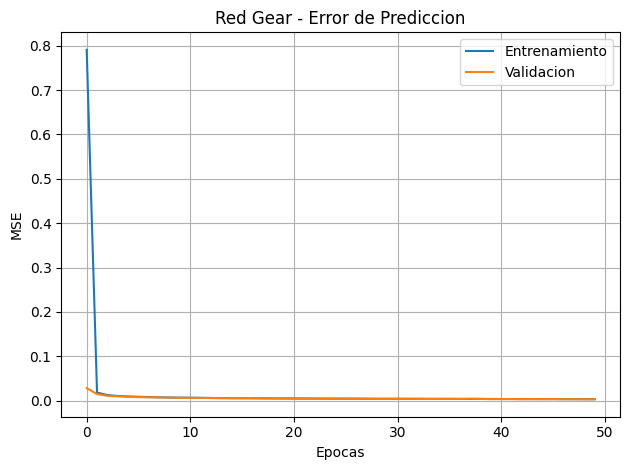

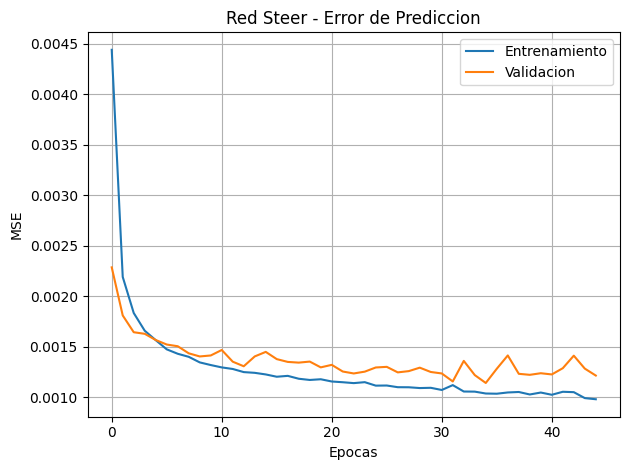

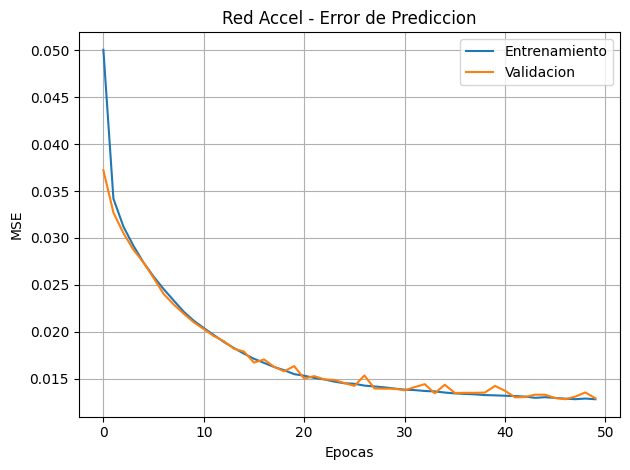

In [9]:
# Grafica Gear
plt.plot(history_gear.history['loss'], label='Entrenamiento')
plt.plot(history_gear.history['val_loss'], label='Validacion')
plt.title('Red Gear - Error de Prediccion')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafica Steer
plt.plot(history_steer.history['loss'], label='Entrenamiento')
plt.plot(history_steer.history['val_loss'], label='Validacion')
plt.title('Red Steer - Error de Prediccion')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafica Accel
plt.plot(history_accel.history['loss'], label='Entrenamiento')
plt.plot(history_accel.history['val_loss'], label='Validacion')
plt.title('Red Accel - Error de Prediccion')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Conversion
signature = (
    tf.TensorSpec(
        (None, X_train_scaled.shape[1]),
        tf.float32,
        name="sensors"
    ),
)

models_to_export = [
    (model_gear,  "IA_gear.onnx"),
    (model_steer, "IA_steer.onnx"),
    (model_accel, "IA_accel.onnx")
]

for modelo, archivo in models_to_export:
    onnx_model, _ = tf2onnx.convert.from_keras(
        modelo,
        input_signature=signature,
        opset=13,
        output_path=archivo
    )
    
    onnx.checker.check_model(onnx_model)

    print(f"Archivo generado: {archivo}")
    print(f"Entrada ONNX: {[i.name for i in onnx_model.graph.input]}")
    print(f"Salida ONNX:  {[o.name for o in onnx_model.graph.output]}")
    print("")

Archivo generado: IA_gear.onnx
Entrada ONNX: ['sensors']
Salida ONNX:  ['gear_output']

Archivo generado: IA_steer.onnx
Entrada ONNX: ['sensors']
Salida ONNX:  ['steer_output']

Archivo generado: IA_accel.onnx
Entrada ONNX: ['sensors']
Salida ONNX:  ['accel_output']



Estadisticas Marchas:

 R2 Score = 0.9977
 Error Medio = 0.0231
 RMSE = 0.0584
 Sesgo Medio = 0.0130
 Error Máximo = 0.8602


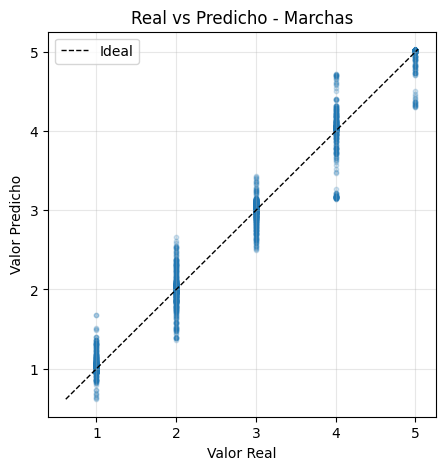

Estadisticas Volante:

 R2 Score = 0.9292
 Error Medio = 0.0106
 RMSE = 0.0337
 Sesgo Medio = 0.0042
 Error Máximo = 0.9260


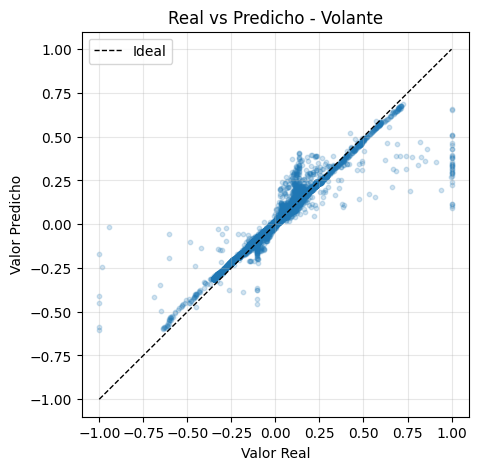

Estadisticas Acelerador:

 R2 Score = 0.9430
 Error Medio = 0.0420
 RMSE = 0.1016
 Sesgo Medio = 0.0188
 Error Máximo = 1.0000


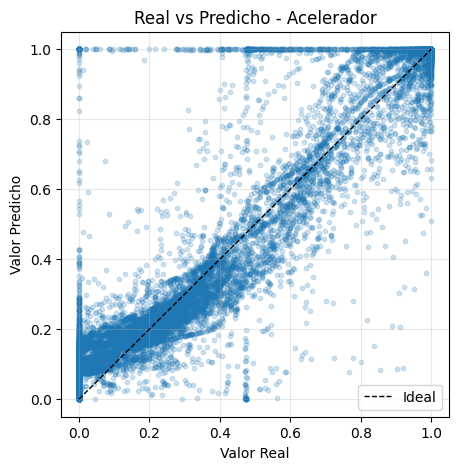

Estadisticas Freno:

 R2 Score = 0.6158
 Error Medio = 0.0400
 RMSE = 0.1244
 Sesgo Medio = -0.0049
 Error Máximo = 0.9999


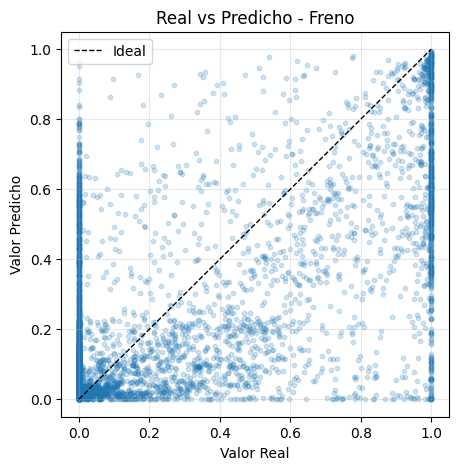

In [38]:
# Predicciones
predicciones_gear = model_gear.predict(X_test_scaled, verbose=0)
predicciones_steer = model_steer.predict(X_test_scaled, verbose=0)
predicciones_accel = model_accel.predict(X_test_scaled, verbose=0)

pred_gear = predicciones_gear.flatten()
pred_steer = predicciones_steer.flatten()
pred_accel = predicciones_accel[:, 0]
pred_brake = predicciones_accel[:, 1]

predicciones_modelo = [pred_gear, pred_steer, pred_accel, pred_brake]
nombres_variables = ['Marchas', 'Volante', 'Acelerador', 'Freno']

for i, nombre in enumerate(nombres_variables):
    real = y_test[:, i]
    pred = predicciones_modelo[i]
    
    r2 = r2_score(real, pred)
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    bias = np.mean(pred - real)
    maxe = np.max(np.abs(pred - real))
    
    print(f"Estadisticas {nombre}:\n")
    print(f" R2 Score = {r2:.4f}")
    print(f" Error Medio = {mae:.4f}")
    print(f" RMSE = {rmse:.4f}")
    print(f" Sesgo Medio = {bias:.4f}")
    print(f" Error Máximo = {maxe:.4f}")

    plt.figure(figsize=(5, 5))
    
    plt.scatter(real, pred, alpha=0.2, s=10)
    
    # Línea ideal (y = x)
    min_val = min(real.min(), pred.min())
    max_val = max(real.max(), pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='Ideal')
    
    plt.title(f"Real vs Predicho - {nombre}")
    plt.xlabel("Valor Real")
    plt.ylabel("Valor Predicho")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.show()